In [ ]:
# =========================================================
# UK HOUSING AFFORDABILITY - TIME SERIES FORECASTING
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from google.colab import drive

In [ ]:
# =========================================================
# 1. DEFINE PROJECT PATHS
# =========================================================

drive.mount('/content/drive')
project_path = "/content/drive/MyDrive/DataAnalytics/UKHousingAffordabilityAnalysis"

processed_data_path = os.path.join(project_path, "Data", "Processed")
figures_path = os.path.join(project_path, "Outputs", "Figures")
tables_path = os.path.join(project_path, "Outputs", "Tables")
metrics_path = os.path.join(project_path, "Outputs", "Metrics")

os.makedirs(figures_path, exist_ok=True)
os.makedirs(tables_path, exist_ok=True)
os.makedirs(metrics_path, exist_ok=True)

Mounted at /content/drive


In [ ]:
# =========================================================
# 2. LOAD PROCESSED DATA
# =========================================================

file_path = os.path.join(
    processed_data_path,
    "UKHousingAffordabilityDataset.csv"
)

df = pd.read_csv(file_path)

print("Dataset loaded:", df.shape)


Dataset loaded: (7255, 10)


In [ ]:
# =========================================================
# 3. FINAL TYPE CLEANING
# =========================================================

numeric_cols = [
    "Year",
    "Affordability_Ratio_Earnings",
    "Affordability_Ratio_Income",
    "Median_House_Price",
    "Median_Earnings"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:

# =========================================================
# 4. BUILD UK-LEVEL TIME SERIES
# =========================================================

uk_ts = (
    df.groupby("Year")["Affordability_Ratio_Earnings"]
    .mean()
    .reset_index()
    .sort_values("Year")
)

print("\nUK time series:")
print(uk_ts.head())



UK time series:
   Year  Affordability_Ratio_Earnings
0  2002                      5.118277
1  2003                      5.886297
2  2004                      6.563544
3  2005                      6.840728
4  2006                      7.029304


In [ ]:


# =========================================================
# 5. TRAIN / TEST SPLIT
# =========================================================

# Last 5 years as test set
test_size = 5

train = uk_ts.iloc[:-test_size].copy()
test = uk_ts.iloc[-test_size:].copy()

print("\nTrain years:", int(train["Year"].min()), "-", int(train["Year"].max()))
print("Test years:", int(test["Year"].min()), "-", int(test["Year"].max()))

y_train = train["Affordability_Ratio_Earnings"].values
y_test = test["Affordability_Ratio_Earnings"].values
x_train = train[["Year"]]
x_test = test[["Year"]]



Train years: 2002 - 2019
Test years: 2020 - 2024


In [ ]:

# =========================================================
# 6. EVALUATION HELPERS
# =========================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred)
    }

results = []

In [ ]:
# =========================================================
# 7. BASELINE 1 - NAIVE
# =========================================================

naive_pred_test = np.repeat(y_train[-1], len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, naive_pred_test))

# =========================================================
# 8. BASELINE 2 - ROLLING MEAN
# =========================================================

rolling_window = 2
rolling_mean_value = train["Affordability_Ratio_Earnings"].tail(rolling_window).mean()
rolling_mean_pred_test = np.repeat(rolling_mean_value, len(y_test))
results.append(evaluate_model("Rolling Mean Baseline (2)", y_test, rolling_mean_pred_test))

# =========================================================
# 9. BASELINE 3 - DRIFT
# =========================================================

y_first = y_train[0]
y_last = y_train[-1]
n_train = len(y_train)

drift_slope = (y_last - y_first) / (n_train - 1)

drift_pred_test = np.array([
    y_last + drift_slope * (i + 1)
    for i in range(len(y_test))
])

results.append(evaluate_model("Drift Baseline", y_test, drift_pred_test))

In [ ]:
# =========================================================
# 10. LINEAR TREND REGRESSION
# =========================================================

lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
lr_pred_test = lr_model.predict(x_test)

results.append(evaluate_model("Linear Trend Regression", y_test, lr_pred_test))

In [ ]:
# =========================================================
# 11. ETS / HOLT EXPONENTIAL SMOOTHING
# =========================================================

ets_model = ExponentialSmoothing(
    train["Affordability_Ratio_Earnings"],
    trend="add",
    seasonal=None
).fit()

ets_pred_test = ets_model.forecast(len(test))
results.append(evaluate_model("ETS / Holt", y_test, ets_pred_test))

In [ ]:
# =========================================================
# 12. ARIMA
# =========================================================

arima_model = ARIMA(
    train["Affordability_Ratio_Earnings"],
    order=(1, 1, 1)
).fit()

arima_pred_test = arima_model.forecast(steps=len(test))
results.append(evaluate_model("ARIMA(1,1,1)", y_test, arima_pred_test))


In [ ]:
# =========================================================
# 13. MODEL COMPARISON TABLE
# =========================================================

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print("\nModel comparison:")
print(results_df)

results_df.to_csv(
    os.path.join(metrics_path, "Forecast_Model_Comparison.csv"),
    index=False
)


Model comparison:
                       Model       MAE      RMSE
0  Rolling Mean Baseline (2)  0.448919  0.507321
1             Naive Baseline  0.462610  0.539990
2    Linear Trend Regression  0.459760  0.581326
3               ARIMA(1,1,1)  0.503584  0.609805
4                 ETS / Holt  0.519969  0.691488
5             Drift Baseline  0.519969  0.691488


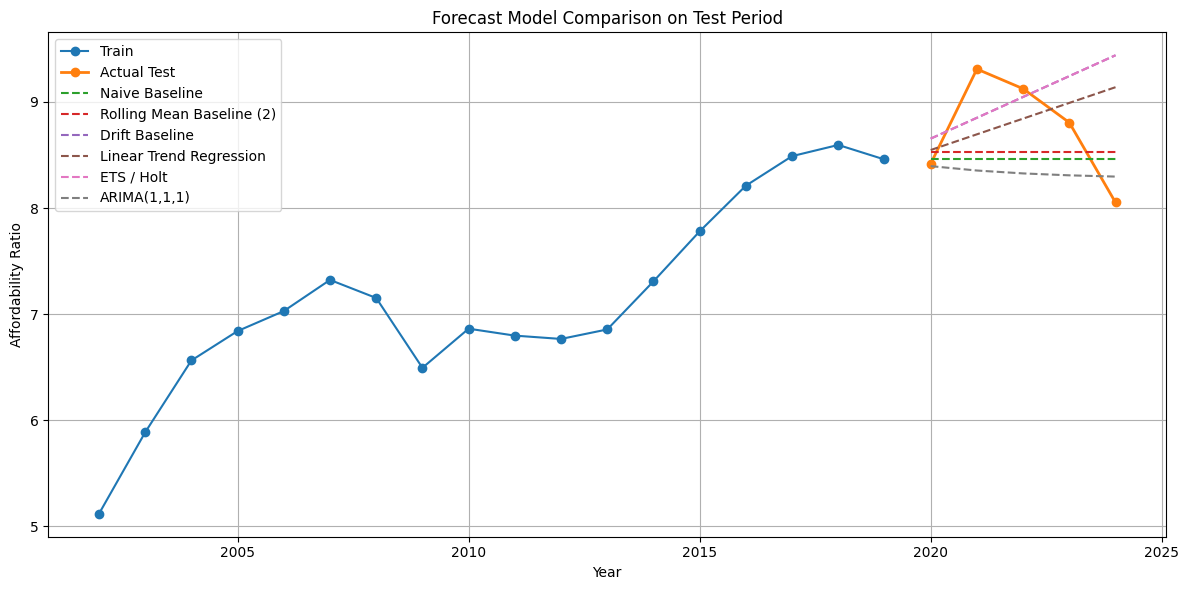

In [ ]:
# =========================================================
# 14. PLOT TEST SET PREDICTIONS
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(train["Year"], train["Affordability_Ratio_Earnings"], label="Train", marker="o")
plt.plot(test["Year"], test["Affordability_Ratio_Earnings"], label="Actual Test", marker="o", linewidth=2)

plt.plot(test["Year"], naive_pred_test, label="Naive Baseline", linestyle="--")
plt.plot(test["Year"], rolling_mean_pred_test, label="Rolling Mean Baseline (2)", linestyle="--")
plt.plot(test["Year"], drift_pred_test, label="Drift Baseline", linestyle="--")
plt.plot(test["Year"], lr_pred_test, label="Linear Trend Regression", linestyle="--")
plt.plot(test["Year"], ets_pred_test, label="ETS / Holt", linestyle="--")
plt.plot(test["Year"], arima_pred_test, label="ARIMA(1,1,1)", linestyle="--")

plt.title("Forecast Model Comparison on Test Period")
plt.xlabel("Year")
plt.ylabel("Affordability Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(figures_path, "Forecast_Model_Comparison.png"))
plt.show()

In [ ]:
# =========================================================
# 15. REFIT BEST MODEL ON FULL SERIES
# =========================================================

best_model_name = results_df.iloc[0]["Model"]
print("\nBest model:", best_model_name)

forecast_horizon = 5

future_years = pd.DataFrame({
    "Year": range(
        int(uk_ts["Year"].max()) + 1,
        int(uk_ts["Year"].max()) + forecast_horizon + 1
    )
})

y_full = uk_ts["Affordability_Ratio_Earnings"].values
x_full = uk_ts[["Year"]]

if best_model_name == "Naive Baseline":
    future_forecast = np.repeat(y_full[-1], forecast_horizon)

elif best_model_name == "Rolling Mean Baseline (2)":
    future_value = uk_ts["Affordability_Ratio_Earnings"].tail(rolling_window).mean()
    future_forecast = np.repeat(future_value, forecast_horizon)

elif best_model_name == "Drift Baseline":
    y_first_full = y_full[0]
    y_last_full = y_full[-1]
    n_full = len(y_full)
    drift_slope_full = (y_last_full - y_first_full) / (n_full - 1)

    future_forecast = np.array([
        y_last_full + drift_slope_full * (i + 1)
        for i in range(forecast_horizon)
    ])

elif best_model_name == "Linear Trend Regression":
    final_lr_model = LinearRegression()
    final_lr_model.fit(x_full, y_full)
    future_forecast = final_lr_model.predict(future_years[["Year"]])

elif best_model_name == "ETS / Holt":
    final_ets_model = ExponentialSmoothing(
        uk_ts["Affordability_Ratio_Earnings"],
        trend="add",
        seasonal=None
    ).fit()
    future_forecast = final_ets_model.forecast(forecast_horizon)

elif best_model_name == "ARIMA(1,1,1)":
    final_arima_model = ARIMA(
        uk_ts["Affordability_Ratio_Earnings"],
        order=(1, 1, 1)
    ).fit()
    future_forecast = final_arima_model.forecast(steps=forecast_horizon)

else:
    raise ValueError(f"Unknown model selected: {best_model_name}")

forecast_df = future_years.copy()
forecast_df["Forecast_Affordability_Ratio"] = np.array(future_forecast)

print("\n5-Year Forecast:")
print(forecast_df)

forecast_df.to_csv(
    os.path.join(tables_path, "UK_5Year_Affordability_Forecast.csv"),
    index=False
)


Best model: Rolling Mean Baseline (2)

5-Year Forecast:
   Year  Forecast_Affordability_Ratio
0  2025                      8.429272
1  2026                      8.429272
2  2027                      8.429272
3  2028                      8.429272
4  2029                      8.429272


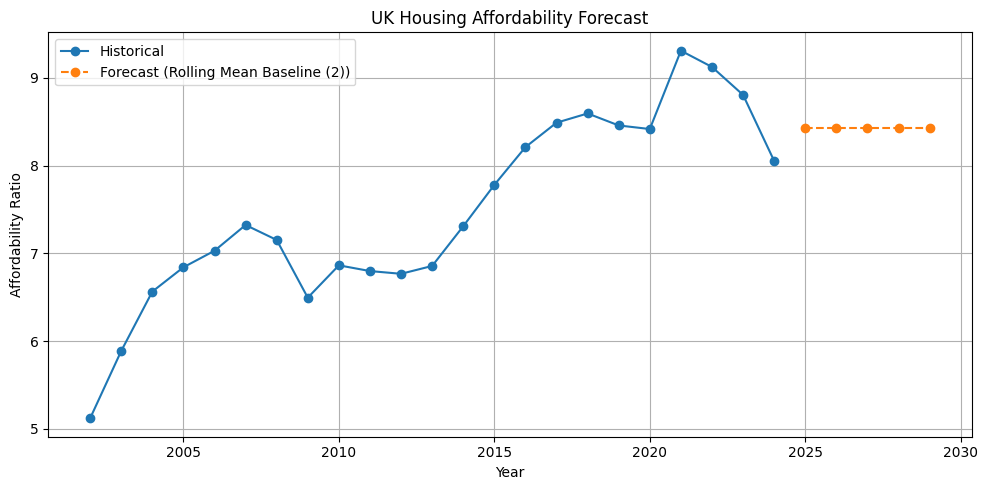

In [ ]:


# =========================================================
# 16. PLOT HISTORICAL + FUTURE FORECAST
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    uk_ts["Year"],
    uk_ts["Affordability_Ratio_Earnings"],
    marker="o",
    label="Historical"
)

plt.plot(
    forecast_df["Year"],
    forecast_df["Forecast_Affordability_Ratio"],
    marker="o",
    linestyle="--",
    label=f"Forecast ({best_model_name})"
)

plt.title("UK Housing Affordability Forecast")
plt.xlabel("Year")
plt.ylabel("Affordability Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(figures_path, "UK_Affordability_5Year_Forecast.png"))
plt.show()

In [ ]:
# =========================================================
# 17. FORECAST SUMMARY
# =========================================================

forecast_summary = pd.DataFrame({
    "Metric": [
        "Best Model",
        "Last Historical Year",
        "Last Historical Ratio",
        "Forecast Start Year",
        "Forecast End Year",
        "Forecast End Ratio"
    ],
    "Value": [
        best_model_name,
        int(uk_ts["Year"].max()),
        round(float(uk_ts["Affordability_Ratio_Earnings"].iloc[-1]), 2),
        int(forecast_df["Year"].min()),
        int(forecast_df["Year"].max()),
        round(float(forecast_df["Forecast_Affordability_Ratio"].iloc[-1]), 2)
    ]
})

print("\nForecast summary:")
print(forecast_summary)

forecast_summary.to_csv(
    os.path.join(tables_path, "Forecast_Summary.csv"),
    index=False
)


Forecast summary:
                  Metric                      Value
0             Best Model  Rolling Mean Baseline (2)
1   Last Historical Year                       2024
2  Last Historical Ratio                       8.05
3    Forecast Start Year                       2025
4      Forecast End Year                       2029
5     Forecast End Ratio                       8.43
